# Unit 0, Lesson 2: Analysis of Poisson Distribution

This is based on my master's introductory probability course at University of L'Aquila, by Prof. Ida Germana Minelli

> Initial retrieval
> 1. What kind of quantity does a Poisson random variable model?
> 2. What is the support of $N\sim\operatorname{Poi}(2)$?
> 3. What does the parameter $2$ mean?
> 4. What is the difference between a random variable, its law, and its probability mass function?

1. A poisson random variable is the limit if a binomial distribution, where you model infinitesimal chances of an event happening at each moment, and determine the number of events that happen in fixed amount of time. For example, for $T \sim \operatorname{Poi}$, we can model $P(T \le 5)$ to see if at most 5 event happen in that time span
2. The support is the natural numbers $\mathbb{N}$
3. The $2$ represents the average amount of events in the specified time period. If the parameter $\lambda$ is higher, say $2 > 1$, that means the event is more likely to occur in any given instant in the interval.
4. A random variable $X$ is simply a function from the sample space $\Omega$ to $\mathbb{R}$ that is measurable. Its law is a function that assigns a probability to Borel subsets of $\mathbb{R}$ where the random variable has support. The probability mass function is the assignment for just a single value in $\mathbb{R}$, and when $X$ is absolutely continuous, the probability density function is a Borel-measurable function.

We know that the poisson distribution models the amount of successes of a binomial distribution $N_n \sim \operatorname{Bin}(n, f)$, where $f=\frac{\lambda}{n}$ is frequency of events in a timescale broken into $n$ slices.
We count the amount of successes $P(N_n = k)$ as $n \to \inf$, which by substituting $p_n = \frac{\lambda}{n}$, yields $e^{-\lambda}\frac{\lambda^k}{k!}$

For Poisson $\operatorname{Poi}(2)$, we have $\bold{p_n} = P(N = k)$ with:
$\bold{p_0} = e^{-2}\frac{2^0}{0!} = e^{-2}$
$\bold{p_1} = e^{-2}\frac{2^1}{1!} = 2e^{-2}$
$\bold{p_2} = e^{-2}\frac{2^2}{2!} = 2e^{-2}$
$\bold{p_3} = e^{-2}\frac{2^3}{3!} = \frac{4}{3}e^{-2}$
$\bold{p_4} = e^{-2}\frac{2^4}{4!} = \frac{2}{3}e^{-2}$

## Reward Function

$$g(n)=n\mathbf1_{\{n\le4\}},\qquad R=g(N)$$

| Reward value $r$ | Event $\{R=r\}$ written using $N$ | $q_r=P(R=r)$ |
|---:|---|---|
| 0 | $\{R=0\} = \{N=0\} \cup \{N\ge5\}$ | $1 - \sum_{r=1}^4\bold{p_r}$ |
| 1 | $\{R=1\} = \{N=1\}$ | $\bold{p_1}$ |
| 4 | $\{R=4\} = \{N=4\}$ | $\bold{p_4}$ |
| 5 | $\{R=5\} = \empty$ | 0 |
| 10 | $\{R=10\} = \empty$ | 0 |

## Expectation Value

$E[R] = \sum\limits_{r=0}^{r=\infty}rP(R=r) \\$
$= 0P(R=0) + \sum\limits_{r=1}^4rP(R=r) + \sum\limits_{r=5}^\infty rP(R=r)\\$
$= 0 + 1 \bold{p_1} + 2 \bold{p_2} + \bold{p_3} + \bold{p_4} + \sum\limits_{r=5}^\infty r(0) \\$
$= 2e^{-2} + 2(2e^{-2}) + 3(\frac{4}{3}e^{-2}) + 4(\frac{2}{3}e^{-2})\\$
$=(2 + 4 + 4 + \frac{8}{3})e^{-2}\\$
$=\frac{38}{3}e^{-2}$

# Poisson in Python

Now we use scipy's `stats` module to model the poisson distribution, and use `matplotlib` to show for reference

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import poisson

mu = 2.0
cutoff=4
# the poisson model is an rv_discrete distribution.
# see https://docs.scipy.org/doc/scipy/reference/generated/scipy.stats.rv_discrete.html#scipy.stats.rv_discrete
poisson_model = poisson(mu=mu)

# print the support, the mean (mu), and the variance
poisson_model.support(), poisson_model.mean(), poisson_model.var()

((np.int64(0), np.float64(inf)), np.float64(2.0), np.float64(2.0))

In [2]:
# Now we perform the modelling for 0-5:
n_values = np.arange(cutoff+2)
probability_poisson = poisson_model.pmf(n_values) # probability mass func
probability_poisson

array([0.13533528, 0.27067057, 0.27067057, 0.18044704, 0.09022352,
       0.03608941])

In [3]:
# the reward function is r * 1_{n <= 4}, so we transform n_values into a bool array
r_law = (n_values <= cutoff) * probability_poisson
r_law[0] = 1 - np.sum(r_law[1:cutoff+1])
reward_exact = n_values * r_law
expectation = np.sum(reward_exact)
numerical_expectation = 38/3*np.exp(-2)

assert round(expectation, 10) == round(numerical_expectation, 10)

expectation

np.float64(1.7142469209970939)

## Random sampling

Perform random sampling from the poisson distribution

In [4]:
rng = np.random.default_rng(314159265)
sample_size = 2000

# use np RandomGenerator to draw from a poisson distribution
# generate 2000 experiments
n_samples = rng.poisson(lam=mu, size=sample_size)
# create reward by filtering to the experiments less than 4, replace the rest with 0's
r_samples = np.where(n_samples <= cutoff, n_samples, 0) 

# count up the distribution for each R:
distribution_empirical = np.bincount(r_samples, minlength=6)
probability_empirical = distribution_empirical/len(r_samples)
reward_empirical = n_values * probability_empirical

{reward: probability for reward, probability in enumerate(probability_empirical)}

{0: np.float64(0.1785),
 1: np.float64(0.282),
 2: np.float64(0.2825),
 3: np.float64(0.1715),
 4: np.float64(0.0855),
 5: np.float64(0.0)}

## Generalizing

Functionalize the generation of the laws and statistical experiments

In [5]:
import numpy.typing as npt
from typing import Dict

def generate_poisson_law(lamb:float=mu, reward_min:int=cutoff) -> (npt.NDArray, npt.NDArray, np.float64):
    poisson_model = poisson(mu=lamb)
    n_values = np.arange(reward_min+2)
    r_law = poisson_model.pmf(n_values)
    r_law[0] = 1 - np.sum(r_law[1:reward_min+1])
    r_law[reward_min+1] = 0

    mean = np.sum(r_law*n_values)
    return n_values, r_law, mean

generate_poisson_law(2, 4)

(array([0, 1, 2, 3, 4, 5]),
 array([0.1879883 , 0.27067057, 0.27067057, 0.18044704, 0.09022352,
        0.        ]),
 np.float64(1.7142469209970939))

In [6]:
from typing import Optional, List
from collections.abc import Iterable

def generate_poisson_experiment(sample_size:int=2000, lamb:float=mu, reward_max:int=cutoff, seed:Optional[int]=42) -> npt.NDArray:
    rng = np.random.default_rng(seed)
    
    n_samples = rng.poisson(lam=lamb, size=sample_size)
    r_samples = np.where(n_samples <= reward_max, n_samples, 0)

    reward_empirical = np.bincount(r_samples, minlength=reward_max+2)
    return reward_empirical

def bins_to_prob(bins:npt.NDArray) -> tuple[npt.NDArray, np.float64]:
    probability = bins/int(sum(bins))
    mean = np.sum(probability*np.arange(len(bins)))
    return probability, mean

bins_to_prob(generate_poisson_experiment(seed=None))

(array([0.1935, 0.2645, 0.281 , 0.176 , 0.085 , 0.    ]),
 np.float64(1.6945000000000001))

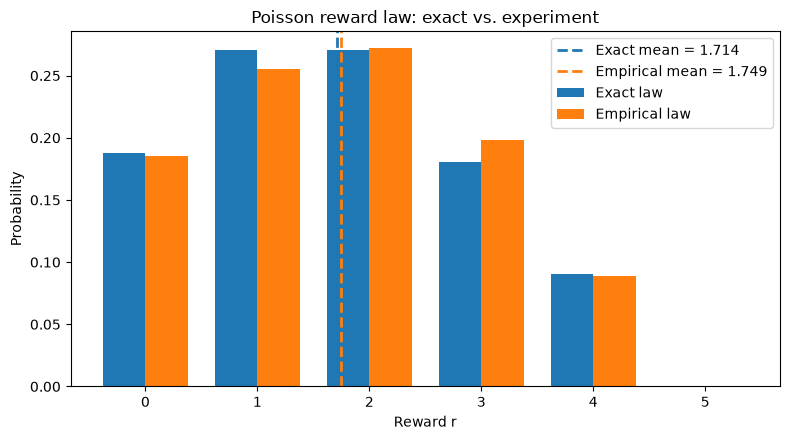

In [7]:
def plot(lamb:int = 2, cutoff:int = 4, samples:int=3000):
    fig, ax = plt.subplots(figsize=(8,4.5))
    width = 0.38
    n_val, law, mean = generate_poisson_law(lamb, cutoff)
    empirical_prob, mean_emp = bins_to_prob(
        generate_poisson_experiment(
            sample_size=samples,
            lamb=lamb,
            reward_max=cutoff,
            seed=None
        )
    )


    ax.bar(n_val - width/2, law, width, label="Exact law")
    ax.bar(n_val + width/2, empirical_prob, width, label="Empirical law")

    ax.axvline(
        mean,
        color="C0",
        linestyle="--",
        linewidth=2,
        label=f"Exact mean = {mean:.3f}"
    )

    ax.axvline(
        mean_emp,
        color="C1",
        linestyle="--",
        linewidth=2,
        label=f"Empirical mean = {mean_emp:.3f}"
    )

    ax.set(
        xlabel="Reward r",
        ylabel="Probability",
        title="Poisson reward law: exact vs. experiment",
    )

    ax.set_xticks(n_val)
    ax.legend()
    fig.tight_layout()
    return fig

fig=plot()
display(fig)
plt.close(fig)

> Interpret the figure Why do the bar heights differ slightly? Which difference is most visually noticeable with this seed? Would another seed produce exactly the same empirical bars? Do not merely say “randomness”; connect the discrepancy to finite sampling.

This is the difference between empirical results sampled FROM a distribution, and the raw distribution itself. 

The probabilities, in the frequentist view, approach the distribution when sampled in increasingly high numbers. That is why we can see that with larger sample sizes, the difference between the reward and the law, on average, tends towards zero

The seed only represents a fixed starting state in the deterministic random number generator, and thus, different seeds generally yield different results. Through the `rng.poisson` utility, the pseudo-random numbers have been mapped to a Poisson distribution. We could, in principle, model the exact probabilities of each number, GIVEN the fixed seed as a Bayesian probability and get deterministic results, but as we move towards quantum computing, we're more interested in repeated sampling.

> **Exit questions**
>
> 1. State the support of $N$ and the support of $R$.
> 2. Why is $q_0>p_0$?
> 3. What problem would renormalizing $p_0,\ldots,p_4$ solve, and why is it not this problem?
> 4. What roles did SciPy and NumPy play, and why did neither replace the derivation?
> 5. In one sentence, what does the classical Monte Carlo estimate target, and what exact value should it approach?

1. The support of $N$ is $\mathbb{N}$, but the support of $R$ is $0...4$ for the cutoff of $4$
2. Since $R=0$ for any $n$ s.t. $n>4$, then the probability $q_0 = p_0 + p_5 + ...$, where all $p_i$ are positive.
3. Renormalization would be useful if we were sampling $P(N = k | N \le 4)$ from a Poisson distribution. This makes it clear that in that scheme, $P(N = 5 | N \le 0) = 0$ This is not our case. In our case, ${5..}$ are possible outcomes in $\Omega$, but since we consider the reward only, we weight them as 0 by the random variable, not give them 0 probability.
4. SciPy provides utilities to easily retrieve probabilities for the distribution, and NumPy allowed us to empirically test the distribution using a pseudo-random generator. NumPy also underlies SciPy and allows for more efficient numerical calculations, at least at scale.
5. Classical Monte Carlo targets the expectation value, emperically created when sampling from a distribution (in this case the poisson distribution) and transforming it into another function (in this case, the cutoff reward function). It should approach $E[R] = \frac{38}{3}e^{-2}$ 

## Extra: interactive component

In [ ]:
import ipywidgets as widgets

sample_size = widgets.BoundedIntText(
    value=3000, 
    min=1, 
    max=1000000, 
    description="Samples:"
)

lambda_slider = widgets.FloatSlider(
    value=4.0,
    min=1.0,
    max=100.0,
    step=1.0,
    description="λ:",
    continuous_update=False
)

cutoff_slider = widgets.IntSlider(
    value=10,
    min=0,
    max=200,
    step=1,
    description="Cutoff:",
    continuous_update=False,
)

run_button = widgets.Button(
    description="Generate experiment",
    button_style="primary",
)

output = widgets.Output()

In [9]:
def render():
    with output:
        output.clear_output(wait=True)

        # create fig
        fig = plot(
            lamb=lambda_slider.value,
            cutoff=cutoff_slider.value,
            samples=sample_size.value
        )
        display(fig)
        plt.close(fig)

In [10]:
run_button.on_click(lambda _: render())
lambda_slider.observe(lambda _: render())
cutoff_slider.observe(lambda _: render())

display(widgets.VBox([
    sample_size,
    lambda_slider,
    cutoff_slider,
    run_button,
    output
]))